<h1>Finetune a RoBERTa model for text classification on donor data</h1>

reference:
https://huggingface.co/docs/transformers/model_doc/roberta#transformers.RobertaForSequenceClassification


Notebook expects train, val, and test files to already be cleaned (de-duplicated full names, remove NaN rows, and one 'full_name' and one 'label' column)

In [ ]:
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from transformers import AutoTokenizer, DataCollatorWithPadding, RobertaForSequenceClassification, TrainingArguments, Trainer 

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import torch


os.environ["WANDB_DISABLED"] = "true"

<h2>Only needed if using google colab to run notebooks:</h2>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Reads in CSV or parquet files and creates device object to use the GPU. Prints 'cuda' if correctly using GPU

In [ ]:
train = pd.read_csv('//content//gdrive//My Drive//DSSI 2025//data//train-undersampled-all-states.csv')
val = pd.read_csv('//content//gdrive//My Drive//DSSI 2025//data//validation-undersampled-all-states.csv')
test = pd.read_parquet('//content//gdrive//My Drive//DSSI 2025//data//Clean_TX.parquet') # Use pd.read_csv if input is a csv file


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def convert_bool(input_label):
    '''
    Converts label to numerical encoding
    '''
    
    if input_label == 'Candidate' or input_label == 'Individual' or input_label == 1:
        return 1
    else:
        return 0

# encode transactor_type as numeric labels
test['label'] = np.vectorize(convert_bool)(test['transactor_type'])

# Deletes all unnecessary columns, only keeps the full name and label 
test = test[['full_name', 'label']]

In [ ]:
# train = train.drop('Unnamed: 0', axis=1)
# val = val.drop('Unnamed: 0', axis=1)
# test = test.drop('Unnamed: 0', axis=1)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def preprocess_function(examples):
    '''
    Tokenize the full_name
    '''
    
    tokenized_inputs = tokenizer(examples["full_name"], truncation=True, padding=True, return_tensors="pt")
    tokenized_inputs = {k:v.to(device) for k, v in tokenized_inputs.items()}
    return tokenized_inputs

In [ ]:
# Convert pandas DataFrame to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train)
val_dataset = Dataset.from_pandas(val)
test_dataset = Dataset.from_pandas(test)

# Define label2id and id2label mappings
label2id = {'0': 0, '1': 1,}
id2label = {0: '0', 1: '1'}

# Apply the preprocess_function to the dataset
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/13324 [00:00<?, ? examples/s]

Map:   0%|          | 0/3332 [00:00<?, ? examples/s]

Map:   0%|          | 0/2777682 [00:00<?, ? examples/s]

In [ ]:
# It’s more efficient to dynamically pad the sentences to the longest length in a batch during collation,
# instead of padding the whole dataset to the maximum length.

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

<h2>To train a new model, continue and Predict here:</h2>

In [ ]:
def compute_metrics(eval_pred):
    '''
    takes in the predictions and calculates scores for accuracy, precision, recall, and f1
    '''
    
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='binary'),
        'recall': recall_score(labels, preds, average='binary'),
        'f1': f1_score(labels, preds, average='binary'),
    }

   
model = RobertaForSequenceClassification.from_pretrained("FacebookAI/roberta-base", num_labels=2, id2label=id2label, label2id=label2id)

model.to(device)

training_args = TrainingArguments(
    output_dir="/content/gdrive/MyDrive/DSSI 2025/roberta",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="best",
    load_best_model_at_end=True,
    push_to_hub=False,
    metric_for_best_model="f1",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

In [ ]:
test_results = trainer.predict(tokenized_test)

predicted_classes = np.argmax(test_results.predictions, axis=1)

print(f1_score(test['label'], predicted_classes))
print(classification_report(test['label'], predicted_classes))

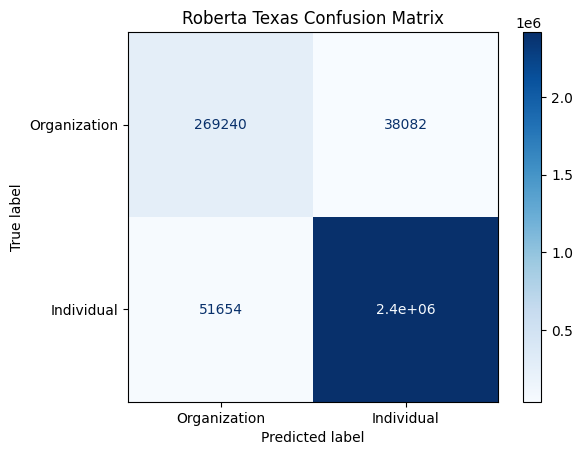

In [ ]:
#Confusion matrix
cm = confusion_matrix(test['label'], predicted_classes, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Roberta Texas Confusion Matrix")
plt.savefig("Roberta Texas Confusion Matrix.png", transparent=True, bbox_inches='tight')
plt.show()

<h2>To Use a pretrained model, Predict here:</h2>

In [ ]:
# Import the model checkpoint here:
model_saved = RobertaForSequenceClassification.from_pretrained("/content/gdrive/MyDrive/PROJECT/my_awesome_model/checkpoint-####")
model_saved.to(device)

trainer = Trainer(model = model_saved)
y_pred_test = trainer.predict(tokenized_test)

# Get the predicted class by finding the index of the maximum logit in each row
predicted_classes_test = np.argmax(y_pred_test.predictions, axis=1)

print(f1_score(test['label'], predicted_classes_test))
print(classification_report(test['label'], predicted_classes_test))

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test, predicted_classes_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Roberta Test Confusion Matrix")
plt.savefig("Roberta Test set.png", transparent=True, bbox_inches='tight')
plt.show()